In [58]:
### Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tqdm

### ML libraries
import xgboost as xgb
import sklearn

### Make up data, and enact an XGBoost Regressor to bootstrap the data

In [55]:
# Generate random training and testing data
np.random.seed(123)  
x_train_data = np.random.rand(150, 8)  
y_train_target = np.random.rand(150)
# Generate 30 samples with 8 features for testing
x_test_data = np.random.rand(30, 8)  

In [56]:
# Number of bootstrapped models
n_it = 150
# List to store predictions from each model
ep_preds = []  

for i in tqdm.tqdm(range(n_it)):
    # Create a bootstrapped dataset 
    sampled_indices = np.random.choice(len(x_train_data), len(x_train_data), replace=True) # Resampling with substitution
    x_resamp_data, y_resamp_target = x_train_data[sampled_indices], y_train_target[sampled_indices]
    
    # Initialize and train
    xgb_model = xgb.XGBRegressor()
    xgb_model.fit(x_resamp_data, y_resamp_target)
    
    # Predict on test data
    test_predictions = xgb_model.predict(x_test_data)
    ep_preds.append(test_predictions)

# Array-ify
ep_preds = np.array(ep_preds)

# Calculate the mean and standard deviation 
avg_preds = np.mean(ep_preds, axis=0)
std_dev_preds = np.std(ep_preds, axis=0)
# print(f"Mean: {avg_preds}")
# print(f"Standard Deviation: {std_dev_preds}")

# Calculate 95% confidence intervals 
lower_sigma = avg_preds - std_dev_preds
upper_sigma = avg_preds + std_dev_preds

100%|██████████| 150/150 [02:10<00:00,  1.15it/s]


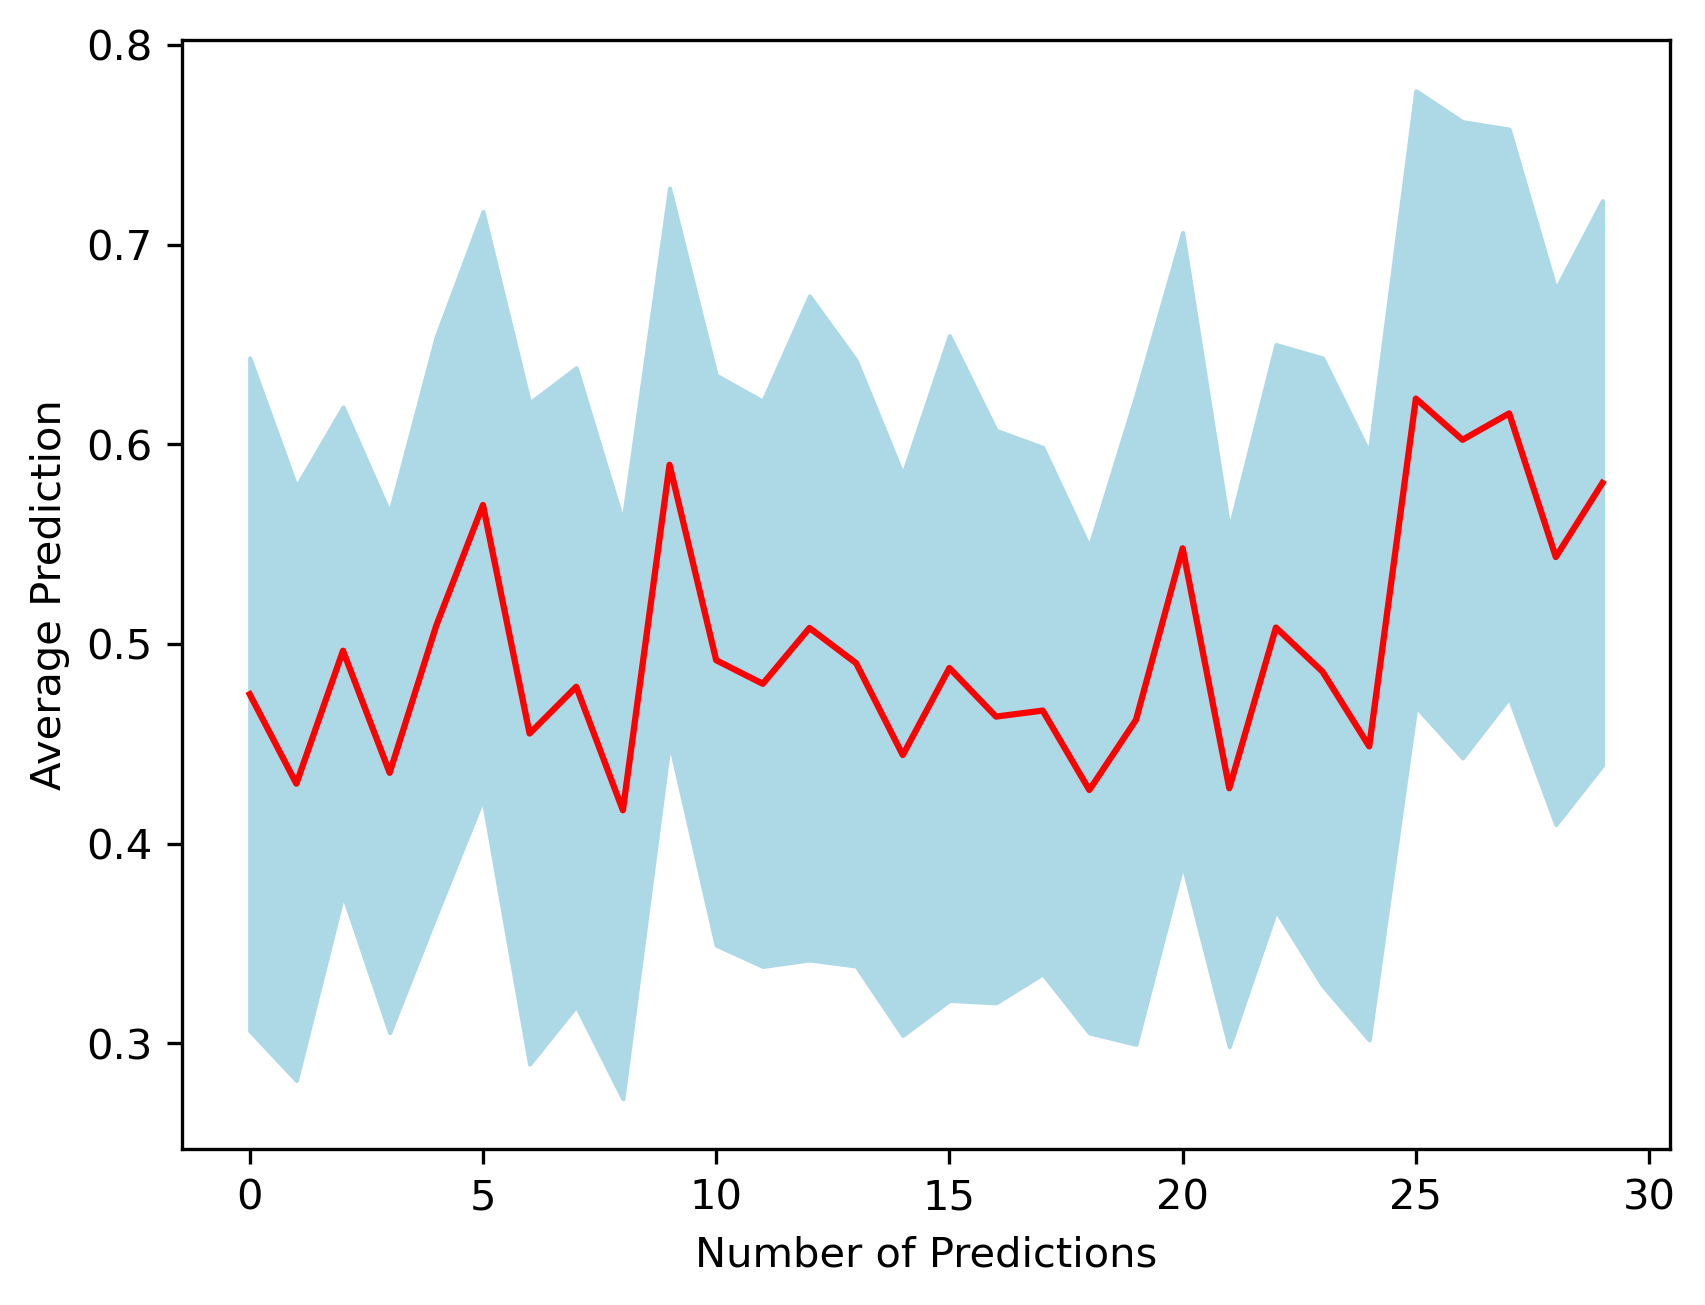

In [53]:
plt.plot(avg_preds, color = "red")
plt.fill_between(range(len(avg_preds)), lower_confidence_bound, upper_confidence_bound, color = "lightblue")
plt.xlabel("Number of Predictions")
plt.ylabel("Average Prediction")
plt.gcf().set_dpi(300)

### Now testing classifier algorithms:

In [63]:
from sklearn.datasets import load_iris # example data found on website
from sklearn.metrics import accuracy_score, classification_report # report metrics for classifier
from sklearn.model_selection import train_test_split # split data from sklearn format

In [66]:
data = load_iris()
X, y = data.data, data.target
x_train, x_test, y_train, y_test = train_test_split(X, y)

In [77]:
model = xgb.XGBClassifier()
model.fit(x_train, y_train)
pred_vals = model.predict(x_test)

In [80]:
print(classification_report(y_test, pred_vals, target_names = data.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        17
  versicolor       1.00      0.90      0.95        10
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        38
   macro avg       0.97      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



### Off-hand classification example: California Housing dataset

In [104]:
from sklearn.datasets import fetch_california_housing

In [114]:
ndata = fetch_california_housing(as_frame = True)
Xz, yz = ndata.data, ndata.target

In [115]:
ndata

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 ...       ...       ...       ...        ...         ...       ...       ...   
 20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
 20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
 20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
 20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
 20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   
 
        Longitude 

In [106]:
# xz_train, yz_train, xz_test, yz_test = train_test_split(Xz,yz)

In [107]:
new_model = xgb.XGBRegressor()

In [108]:
new_model.fit(xz_train, yz_train)

XGBoostError: [02:33:10] /home/conda/feedstock_root/build_artifacts/xgboost-split_1700181168148/work/src/data/data.cc:455: Check failed: this->labels.Size() % this->num_row_ == 0 (10320 vs. 0) : Incorrect size for labels.
Stack trace:
  [bt] (0) /cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/libxgboost.so(+0xb6361) [0x7fbad8f7c361]
  [bt] (1) /cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/libxgboost.so(xgboost::MetaInfo::SetInfoFromHost(xgboost::GenericParameter const&, xgboost::StringView, xgboost::Json)+0x2ac2) [0x7fbad90792c2]
  [bt] (2) /cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/libxgboost.so(xgboost::MetaInfo::SetInfo(xgboost::GenericParameter const&, xgboost::StringView, xgboost::StringView)+0x80) [0x7fbad9079490]
  [bt] (3) /cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/libxgboost.so(XGDMatrixSetInfoFromInterface+0xec) [0x7fbad8f7ef4c]
  [bt] (4) /cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/python3.11/lib-dynload/../../libffi.so.8(+0x6d8a) [0x7fbb26b86d

In [109]:
ndata

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [96]:
np.shape(xz_train)

(15480, 8)

In [97]:
np.shape(yz_train)

(5160, 8)